In [1]:
from transformers import Sam3Processor, Sam3Model
import torch
from PIL import Image
import requests

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
model = Sam3Model.from_pretrained("facebook/sam3").to(device)
processor = Sam3Processor.from_pretrained("facebook/sam3")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

processor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/799 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

In [4]:
# Load image
image_path = "./pedestrian.png"
image = Image.open(image_path).convert("RGB")

In [13]:
# Segment using text prompt
inputs = processor(images=image, text="pedestrian", return_tensors="pt").to(device)

In [14]:
with torch.no_grad():
    outputs = model(**inputs)

In [15]:
# Post-process results
results = processor.post_process_instance_segmentation(
    outputs,
    threshold=0.5,
    mask_threshold=0.5,
    target_sizes=inputs.get("original_sizes").tolist()
)[0]

In [16]:
print(f"Found {len(results['masks'])} objects")

Found 21 objects


In [17]:
results

{'scores': tensor([0.8482, 0.5761, 0.9561, 0.8126, 0.9535, 0.9063, 0.8038, 0.9539, 0.9377,
         0.9396, 0.9410, 0.8783, 0.8709, 0.9585, 0.9380, 0.9438, 0.9514, 0.9458,
         0.9476, 0.5396, 0.9443]),
 'boxes': tensor([[ 9.4409e+02, -5.2607e-01,  9.6631e+02,  4.0661e+01],
         [ 9.0894e+02, -1.0526e+00,  9.2578e+02,  6.4773e+00],
         [ 8.2917e+02,  3.7140e+02,  9.0042e+02,  4.8226e+02],
         [-4.3615e-01,  4.5238e+02,  2.7470e+01,  4.8269e+02],
         [ 1.0028e+03,  1.6203e+02,  1.0594e+03,  2.5388e+02],
         [ 5.8218e+02,  2.3257e+02,  6.5129e+02,  3.4170e+02],
         [ 2.2432e+01,  4.1300e+02,  1.0047e+02,  4.8241e+02],
         [ 2.6958e+02,  1.5256e+02,  3.2937e+02,  2.5276e+02],
         [ 8.5071e+02,  1.8227e+02,  8.8355e+02,  2.8199e+02],
         [ 3.4387e+02,  2.0841e+02,  3.8172e+02,  3.1098e+02],
         [ 3.4947e+02,  1.1060e+02,  3.8893e+02,  1.9534e+02],
         [ 2.7666e+02,  1.5384e+02,  3.2954e+02,  2.3691e+02],
         [ 9.6805e+02, -1.41

In [18]:
import numpy as np
import matplotlib

def overlay_masks(image, masks):
    image = image.convert("RGBA")
    masks = 255 * masks.cpu().numpy().astype(np.uint8)

    n_masks = masks.shape[0]
    cmap = matplotlib.colormaps.get_cmap("rainbow").resampled(n_masks)
    colors = [
        tuple(int(c * 255) for c in cmap(i)[:3])
        for i in range(n_masks)
    ]

    for mask, color in zip(masks, colors):
        mask = Image.fromarray(mask)
        overlay = Image.new("RGBA", image.size, color + (0,))
        alpha = mask.point(lambda v: int(v * 0.5))
        overlay.putalpha(alpha)
        image = Image.alpha_composite(image, overlay)
    return image


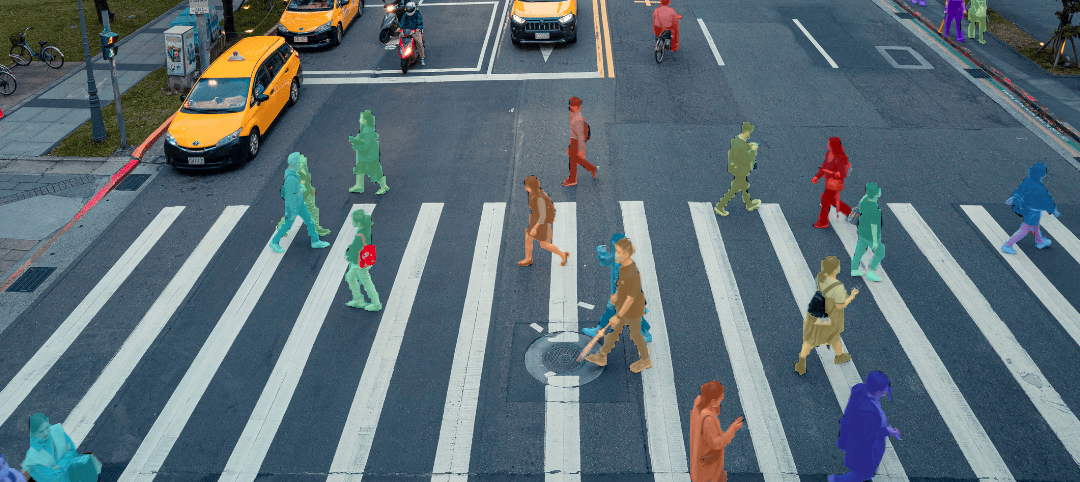

In [19]:
overlay_masks(image, results["masks"])

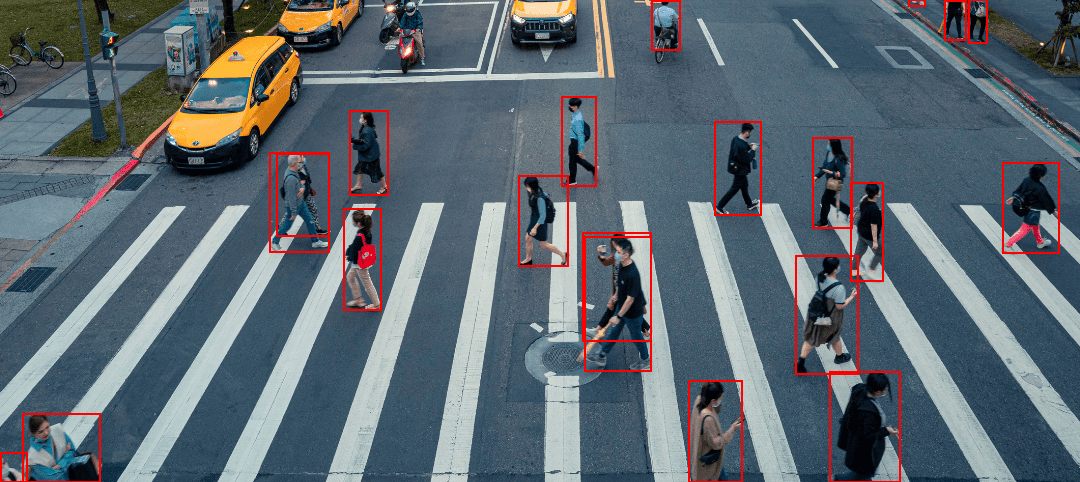

In [20]:
from PIL import ImageDraw

# Create a copy of the original image to draw on
image_with_boxes = image.copy()
draw = ImageDraw.Draw(image_with_boxes)

# Get the bounding boxes from the results
boxes = results['boxes'].cpu().numpy()

# Draw each bounding box on the image
for box in boxes:
    x_min, y_min, x_max, y_max = box
    # ImageDraw.rectangle expects (x0, y0, x1, y1) tuple
    draw.rectangle([x_min, y_min, x_max, y_max], outline="red", width=2)

# Display the image with bounding boxes
display(image_with_boxes)

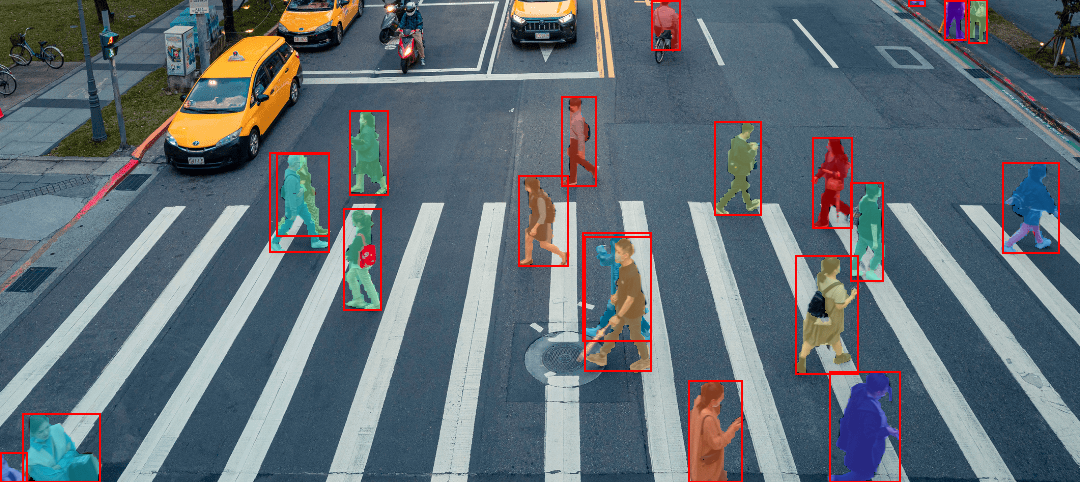

In [21]:
from PIL import ImageDraw

# Create a copy of the segmented image to draw on
image_with_boxes = overlay_masks(image, results["masks"]).copy()
draw = ImageDraw.Draw(image_with_boxes)

# Get the bounding boxes from the results
boxes = results['boxes'].cpu().numpy()

# Draw each bounding box on the image
for box in boxes:
    x_min, y_min, x_max, y_max = box
    # ImageDraw.rectangle expects (x0, y0, x1, y1) tuple
    draw.rectangle([x_min, y_min, x_max, y_max], outline="red", width=2)

# Display the image with bounding boxes and segmentation
display(image_with_boxes)